In [5]:
from rdkit import Chem
from rdkit.Chem import rdDetermineBonds
import numpy as np
import pandas as pd 
from scipy.spatial.transform import Rotation as R
from scipy.spatial.distance import pdist, squareform
from pathlib import Path 
import tqdm
import umap
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
import matplotlib.patches as mpatches


In [6]:
def xyz_to_rdkit_mol(xyz_file, total_charge):
    """
    Convert an XYZ file with explicit hydrogens to an RDKit Mol,
    preserving 3D coordinates and determining connectivity automatically.
    

    Parameters:
        xyz_file: path to XYZ file
        total_charge: total molecular charge (default 0)
    
    Returns:
        RDKit Mol object
    """
    # --- Read XYZ ---
    with open(xyz_file) as f:
        lines = f.readlines()[2:]  # skip atom count + comment
    atoms, coords = [], []

    for line in lines:
        parts = line.split()
        atoms.append(parts[0])
        coords.append([float(x) for x in parts[1:4]])
    coords = np.array(coords)
    
    # --- Create empty molecule with atoms ---
    mol = Chem.RWMol()
    z = [Chem.GetPeriodicTable().GetAtomicNumber(a) for a in atoms]
    for Zi in z:
        mol.AddAtom(Chem.Atom(Zi))
    
    # --- Add coordinates ---
    conf = Chem.Conformer(len(coords))
    for i, pos in enumerate(coords):
        conf.SetAtomPosition(i, pos)
    mol.AddConformer(conf)
    
    # --- Determine connectivity using RDKit's bond perception ---
    Chem.rdDetermineBonds.DetermineConnectivity(mol, charge=total_charge)
    
    # --- Sanitize molecule ---
    Chem.SanitizeMol(mol)
    
    return mol




In [ ]:
raw_spawns_folder = Path('/Users/connerbaucom/Desktop/Pieri/CTG/dim_red_comp/PhotoStats/data/raw_geometries/spawn/ethylene')
mecis = [ 
   Path('../../../data/raw_geometries/meci/ethylene_main_meci/Twist.xyz'),
    Path('../../../data/raw_geometries/meci/ethylene_main_meci/Ethylidene.xyz'),
    Path('../../../data/raw_geometries/meci/ethylene_main_meci/H-Dissociation.xyz')
]


In [34]:
idx = []
list_of_sorted_eigenvalues = []


for x in tqdm.tqdm(list(raw_spawns_folder.glob('*'))):
    mol = xyz_to_rdkit_mol(x,total_charge=0)

    matrix = 1 / ( Chem.Get3DDistanceMatrix(mol) + .001)
    eigenvalues = np.linalg.eigvals(matrix)
    sorted_eigenvalues = np.sort(eigenvalues)
    idx.append(x.stem)
    list_of_sorted_eigenvalues.append(sorted_eigenvalues)


#for meci in mecis:

#    mol = xyz_to_rdkit_mol(meci,total_charge=0)
#    matrix = 1 / ( Chem.Get3DDistanceMatrix(mol) + .001)
#    eigenvalues = np.linalg.eigvals(matrix)
#    sorted_eigenvalues = np.sort(eigenvalues)
#    list_of_sorted_eigenvalues.append(sorted_eigenvalues)

#   idx.append(meci.stem)

feature_vector = np.array(list_of_sorted_eigenvalues)







100%|██████████| 2557/2557 [00:00<00:00, 6569.84it/s]


['0648_2', '0470_3', '0299_2', '0435_3', '0572_4', '0022_5', '0861_5', '0318_3', '0120_2', '0165_2', '0926_2', '0198_2', '0771_3', '0549_2', '0734_3', '0636_4', '0673_4', '0221_2', '0019_3', '0264_2', '0013_13', '0513_5', '0187_5', '0454_2', '0085_2', '0411_2', '0629_3', '0535_6', '0947_3', '0104_3', '0902_3', '0141_3', '0590_3', '0379_2', '0845_4', '0006_4', '0612_5', '0384_2', '0755_2', '0710_2', '0205_3', '0078_2', '0691_3', '0240_3', '0939_5', '0307_4', '0885_4', '0181_3', '0768_2', '0550_3', '0494_2', '0806_2', '0045_2', '0238_3', '0843_2', '0000_2', '0013_8', '0102_5', '0382_4', '0753_4', '0614_3', '0651_3', '0469_2', '0280_3', '0344_2', '0795_2', '0301_2', '0139_3', '0878_4', '0531_2', '0709_3', '0574_2', '0061_3', '0822_3', '0688_2', '0259_2', '0867_3', '0408_3', '0630_2', '0675_2', '0777_5', '0262_4', '0158_2', '0589_2', '0360_3', '0325_3', '0360_2', '0589_3', '0158_3', '0325_2', '0777_4', '0630_3', '0408_2', '0675_3', '0259_3', '0688_3', '0822_2', '0061_2', '0867_2', '0024_2'

/opt/homebrew/anaconda3/envs/conf-align/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/opt/homebrew/anaconda3/envs/conf-align/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/opt/homebrew/anaconda3/envs/conf-align/lib/python3.12/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/opt/homebrew/anaconda3/envs/conf-align/lib/python3.12/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/opt/homebrew/anaconda3/envs/conf-align/lib/python3.12/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/opt/homebrew/anaconda3/envs/conf-align/lib/python3.12/site-packages/sklearn/cluster/_kmea

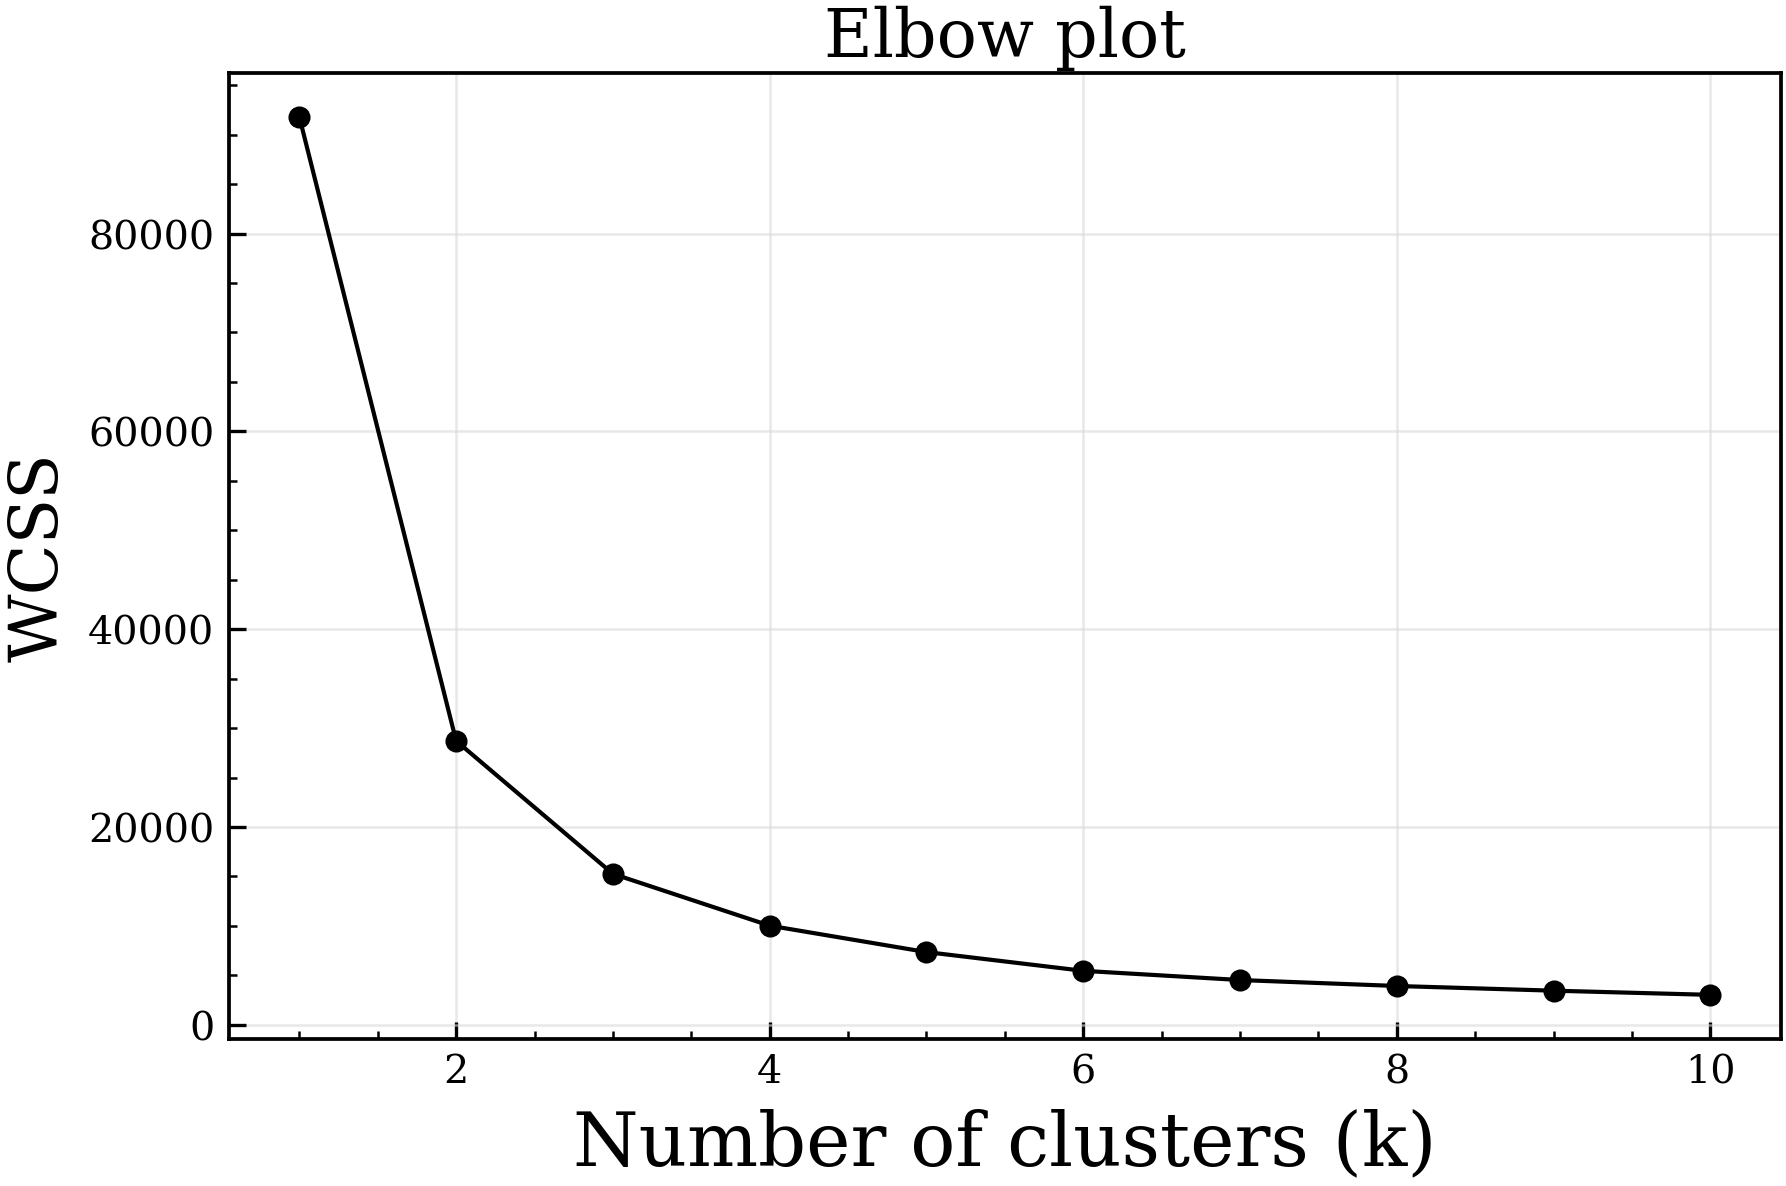

In [37]:
reducer = umap.UMAP(
        n_components=2,
        n_neighbors=10,
        min_dist=0.1,
        random_state=42
    )
X_umap = reducer.fit_transform(feature_vector)


wcss = []
k_range = range(1, min(11, len(X_umap)))
for k in k_range:
    kmeans = KMeans(n_clusters=k, init="k-means++", n_init=10, random_state=42)
    kmeans.fit(X_umap)
    wcss.append(kmeans.inertia_)
plt.style.use("/Users/connerbaucom/Desktop/Pieri/CTG/dim_red_comp/PhotoStats/prl.mplstyle")

plt.figure(figsize=(6, 4))
plt.plot(k_range, wcss, marker="o")
plt.xlabel("Number of clusters (k)", fontsize=18)
plt.ylabel("WCSS",fontsize=16)
plt.title(f"Elbow plot", fontsize=16)
plt.grid(True)
plt.show()



/opt/homebrew/anaconda3/envs/conf-align/lib/python3.12/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/opt/homebrew/anaconda3/envs/conf-align/lib/python3.12/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/opt/homebrew/anaconda3/envs/conf-align/lib/python3.12/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/opt/homebrew/anaconda3/envs/conf-align/lib/python3.12/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: divide by zero encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/opt/homebrew/anaconda3/envs/conf-align/lib/python3.12/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: overflow encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/opt/homebrew/anaconda3/envs/conf-align/lib/python3.12/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWar

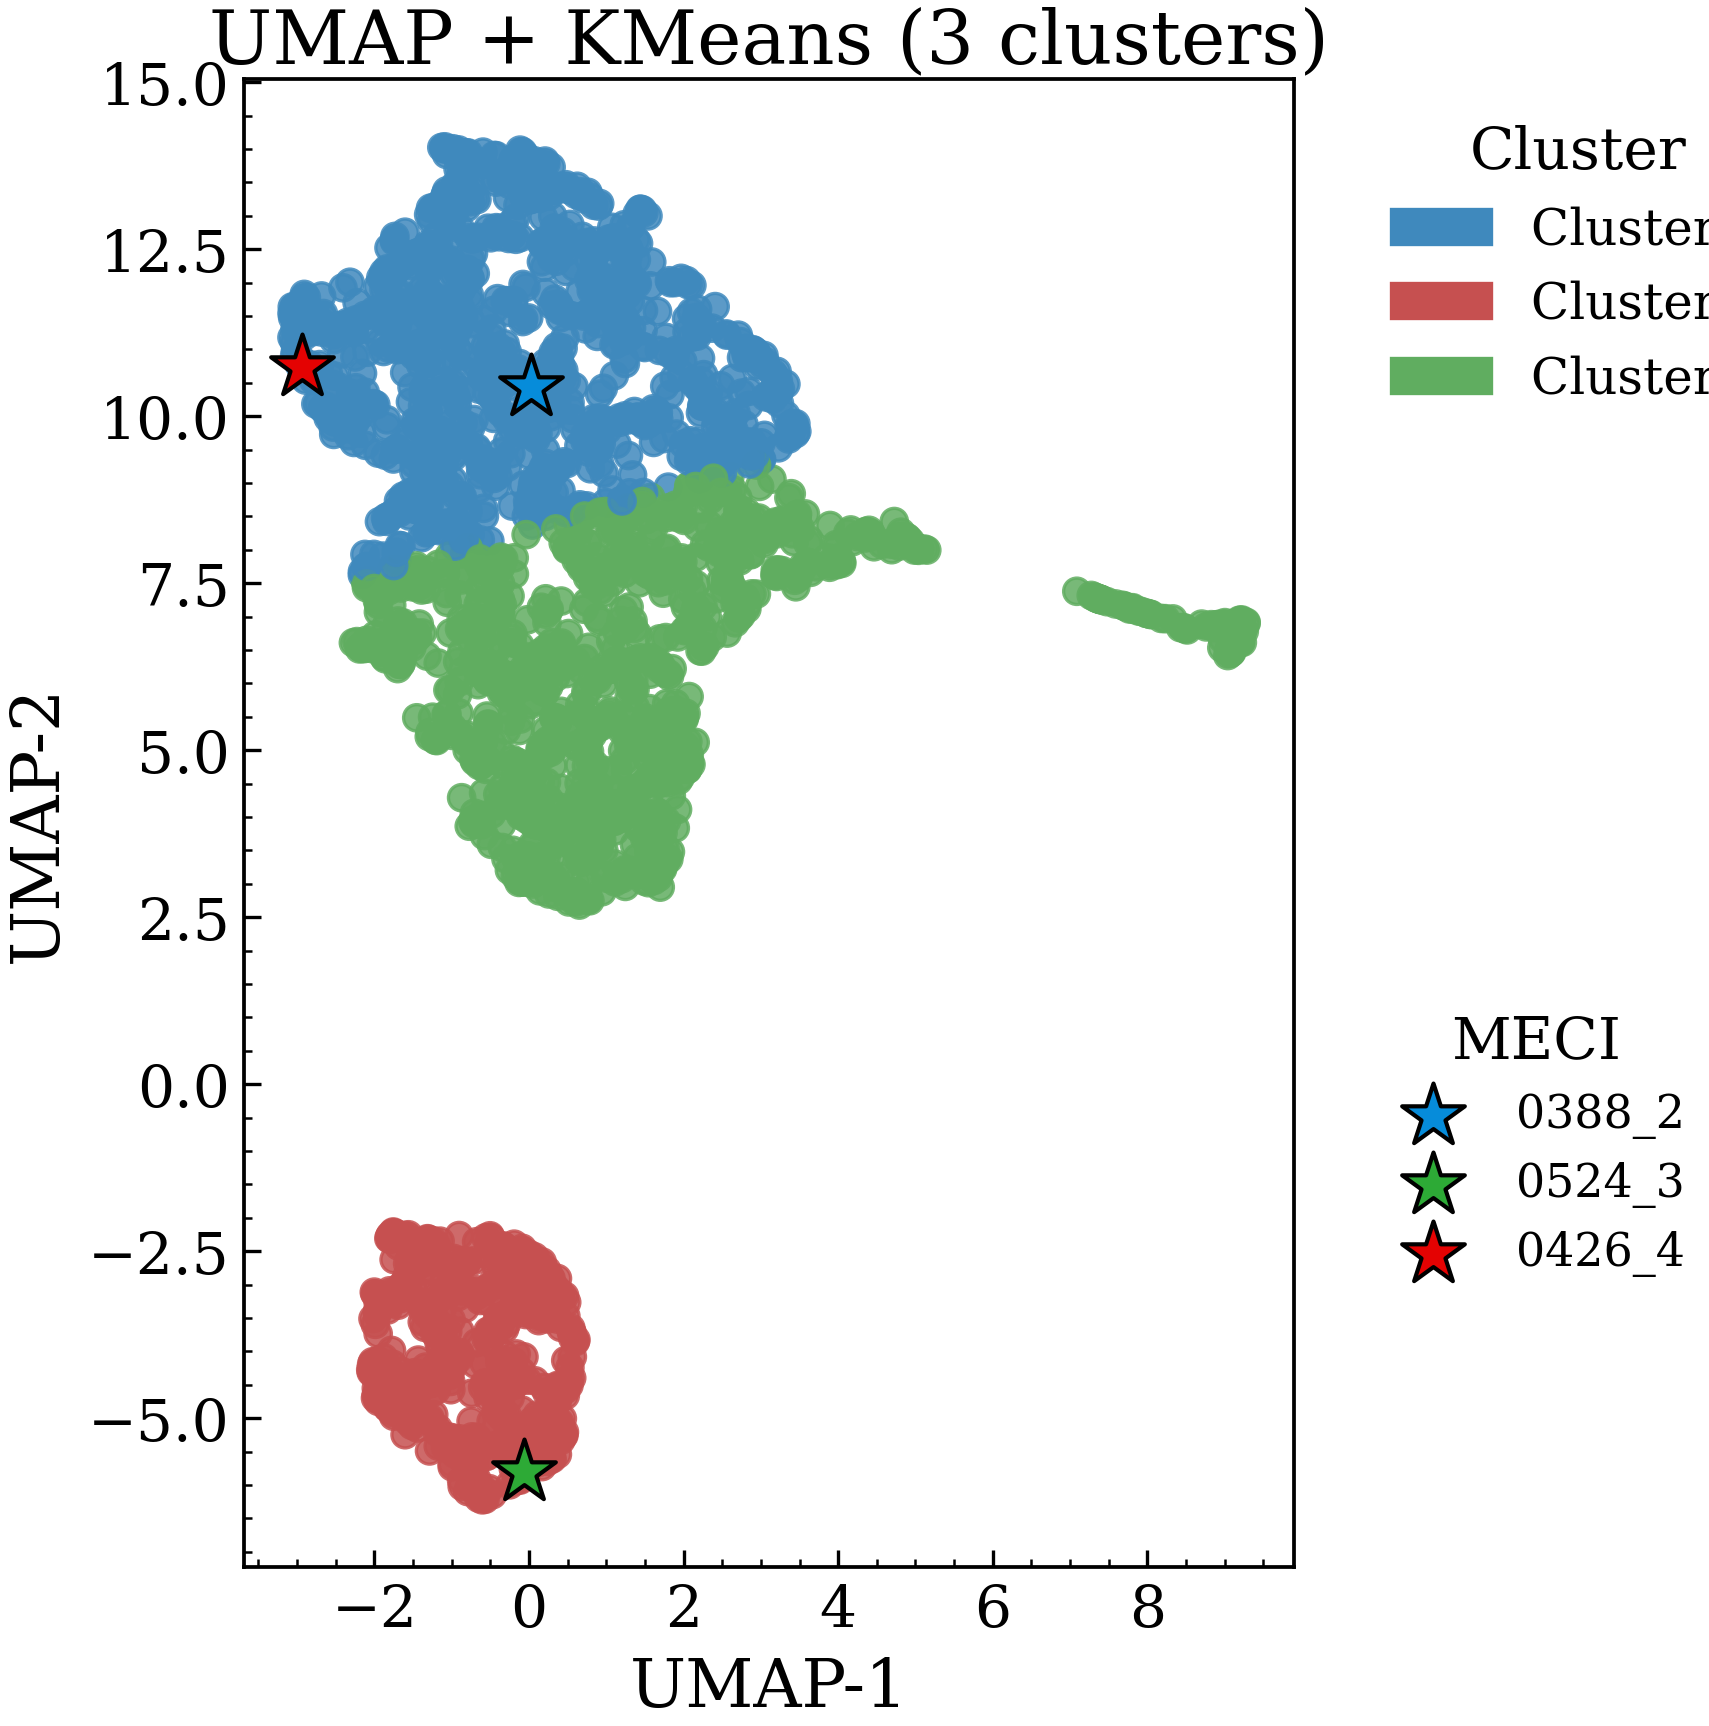

In [38]:
optimal_k = 3

kmeans = KMeans(n_clusters=optimal_k, init="k-means++", n_init=10, random_state=42)
labels = kmeans.fit_predict(X_umap)

output_rows =[]

for idx_val, cluster_val in zip(idx, labels):
    output_rows.append([idx_val.stem if isinstance(idx_val, Path) else str(idx_val),
                        cluster_val])


import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap
import numpy as np

# -----------------------------
# Configuration
# -----------------------------
optimal_k = 3
n_star = 3                    # how many last datapoints to highlight
star_size = 250
point_size = 40

# Cluster colors
cluster_colors = [
    "#3f89bd",  # cluster 0
    "#c65050",  # cluster 1
    "#60ad60",  # cluster 2
]

# ⭐ Manually chosen star colors (one per starred point, in order)
star_colors = [
    "#068cda",  # red
    "#2daa36",  # purple
    "#e40202",  # green
]

cmap = ListedColormap(cluster_colors)

# Indices of starred points (last n)
star_indices = np.arange(len(X_umap) - n_star, len(X_umap))

# -----------------------------
# Plot
# -----------------------------
plt.figure(figsize=(6, 6))

# Normal points
plt.scatter(
    X_umap[:, 0],
    X_umap[:, 1],
    c=labels,
    cmap=cmap,
    s=point_size,
    alpha=0.85
)

# Starred points (plotted on top)
star_handles = []
for i, star_idx in enumerate(star_indices):
    h = plt.scatter(
        X_umap[star_idx, 0],
        X_umap[star_idx, 1],
        marker="*",
        s=star_size,
        color=star_colors[i],   # ⭐ manual color
        edgecolor="black",
        linewidth=1.0,
        zorder=10,
        label=str(idx[star_idx].stem if hasattr(idx[star_idx], "stem") else idx[star_idx])
    )
    star_handles.append(h)

# -----------------------------
# Labels & formatting
# -----------------------------
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.title(f"UMAP + KMeans ({optimal_k} clusters)", fontsize=18)
plt.xlabel("UMAP-1", fontsize=16)
plt.ylabel("UMAP-2", fontsize=16)
plt.grid(False)

# -----------------------------
# Legends
# -----------------------------
# Cluster legend
cluster_patches = [
    mpatches.Patch(color=cluster_colors[i], label=f"Cluster {i}")
    for i in sorted(set(labels))
]

cluster_legend = plt.legend(
    handles=cluster_patches,
    title="Cluster",
    bbox_to_anchor=(1.05, 1),
    loc="upper left",
    title_fontsize=14,
    fontsize=12
)

# Star legend (idx names)
star_legend = plt.legend(
    handles=star_handles,
    title="MECI",
    bbox_to_anchor=(1.05, 0.4),
    loc="upper left",
    title_fontsize=14,
    fontsize=11
)

plt.gca().add_artist(cluster_legend)

plt.tight_layout()
plt.show()


In [16]:
print(output_rows)

[['0648_2', np.int32(1)], ['0470_3', np.int32(1)], ['0299_2', np.int32(2)], ['0435_3', np.int32(1)], ['0572_4', np.int32(0)], ['0022_5', np.int32(1)], ['0861_5', np.int32(2)], ['0318_3', np.int32(1)], ['0120_2', np.int32(0)], ['0165_2', np.int32(0)], ['0926_2', np.int32(2)], ['0198_2', np.int32(1)], ['0771_3', np.int32(0)], ['0549_2', np.int32(1)], ['0734_3', np.int32(2)], ['0636_4', np.int32(1)], ['0673_4', np.int32(0)], ['0221_2', np.int32(1)], ['0019_3', np.int32(0)], ['0264_2', np.int32(0)], ['0013_13', np.int32(2)], ['0513_5', np.int32(2)], ['0187_5', np.int32(2)], ['0454_2', np.int32(2)], ['0085_2', np.int32(1)], ['0411_2', np.int32(2)], ['0629_3', np.int32(2)], ['0535_6', np.int32(2)], ['0947_3', np.int32(2)], ['0104_3', np.int32(2)], ['0902_3', np.int32(1)], ['0141_3', np.int32(2)], ['0590_3', np.int32(2)], ['0379_2', np.int32(0)], ['0845_4', np.int32(0)], ['0006_4', np.int32(0)], ['0612_5', np.int32(2)], ['0384_2', np.int32(0)], ['0755_2', np.int32(1)], ['0710_2', np.int32(2)]

In [36]:
df = pd.DataFrame(output_rows, columns=["idx", "cluster"])
csv_path = "../../..//data/clustered/no_smiles/inv_eigenvals/umap/kmeans/cluster_assignments.csv"
df.to_csv(csv_path, index=False)
